In [18]:
import pandas as pd
import numpy as np 

np.random.seed(42)
n=1000

locations=['Mumbai','Delhi','Pune','Bangalore','Chennai']
evidence_types = ['CCTV', 'Logs', 'Witness', 'Documents', 'Forensic']
crime_types = ['Theft', 'Cyber Crime', 'Assault', 'Fraud', 'Robbery']
statuses = ['Open', 'Closed', 'Pending']

df = pd.DataFrame({
    'location': np.random.choice(locations, n),
    'evidence_type': np.random.choice(evidence_types, n),
    'status': np.random.choice(statuses, n),
    'month': np.random.randint(1, 13, n),
    'weekday': np.random.randint(0, 7, n),
    'crime_type': np.random.choice(crime_types, n)
})

print(df.shape)
print(df.head())
print(df['crime_type'].value_counts())

(1000, 6)
    location evidence_type   status  month  weekday   crime_type
0  Bangalore     Documents  Pending      8        6  Cyber Crime
1    Chennai     Documents  Pending      5        3      Assault
2       Pune     Documents   Closed      3        3        Fraud
3    Chennai     Documents     Open      6        3      Assault
4    Chennai      Forensic   Closed      4        5        Fraud
crime_type
Fraud          222
Assault        199
Robbery        198
Cyber Crime    196
Theft          185
Name: count, dtype: int64


In [19]:
from sklearn.preprocessing import LabelEncoder

# Encode categorical features
X = pd.get_dummies(df[['location', 'evidence_type', 'status', 'month', 'weekday']],
                   columns = ['location', 'evidence_type', 'status'],
                   drop_first=True)

y = df['crime_type']

print("Features shape:", X.shape)
print("Target distribution:\n", y.value_counts())

Features shape: (1000, 12)
Target distribution:
 crime_type
Fraud          222
Assault        199
Robbery        198
Cyber Crime    196
Theft          185
Name: count, dtype: int64


In [20]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score

# Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Training size:", X_train.shape)
print("Testing size:", X_test.shape)

Training size: (800, 12)
Testing size: (200, 12)


In [21]:
# Train Random Forest
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)

# Train Logistic Regression
lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train, y_train)
lr_pred = lr_model.predict(X_test)

# Compare
print("=== Random Forest ===")
print("Accuracy:", round(accuracy_score(y_test, rf_pred), 3))
print(classification_report(y_test, rf_pred))

print("=== Logistic Regression ===")
print("Accuracy:", round(accuracy_score(y_test, lr_pred), 3))
print(classification_report(y_test, lr_pred))

=== Random Forest ===
Accuracy: 0.21
              precision    recall  f1-score   support

     Assault       0.17      0.18      0.18        38
 Cyber Crime       0.36      0.20      0.25        51
       Fraud       0.26      0.31      0.28        39
     Robbery       0.20      0.25      0.22        36
       Theft       0.10      0.11      0.11        36

    accuracy                           0.21       200
   macro avg       0.22      0.21      0.21       200
weighted avg       0.23      0.21      0.21       200

=== Logistic Regression ===
Accuracy: 0.21
              precision    recall  f1-score   support

     Assault       0.22      0.16      0.18        38
 Cyber Crime       0.38      0.16      0.22        51
       Fraud       0.20      0.46      0.28        39
     Robbery       0.17      0.22      0.19        36
       Theft       0.14      0.06      0.08        36

    accuracy                           0.21       200
   macro avg       0.22      0.21      0.19       2

## Experiment 2 — Realistic Synthetic Data
Adding domain-based patterns (evidence type determines crime type).
Expected result: significantly better accuracy.

In [22]:
np.random.seed(42)
n = 1000

data = []

for _ in range(n):
    location = np.random.choice(locations)
    evidence_type = np.random.choice(evidence_types)
    status = np.random.choice(statuses)
    month = np.random.randint(1, 13)
    weekday = np.random.randint(0, 7)
    
    # Realistic patterns
    if evidence_type == 'Logs':
        crime_type = np.random.choice(['Cyber Crime', 'Fraud'], p=[0.7, 0.3])
    elif evidence_type == 'CCTV':
        crime_type = np.random.choice(['Theft', 'Robbery', 'Assault'], p=[0.5, 0.3, 0.2])
    elif evidence_type == 'Witness':
        crime_type = np.random.choice(['Assault', 'Robbery', 'Theft'], p=[0.6, 0.2, 0.2])
    elif evidence_type == 'Documents':
        crime_type = np.random.choice(['Fraud', 'Cyber Crime'], p=[0.8, 0.2])
    else:  # Forensic
        crime_type = np.random.choice(['Assault', 'Robbery'], p=[0.6, 0.4])
    
    data.append([location, evidence_type, status, month, weekday, crime_type])

df = pd.DataFrame(data, columns=['location', 'evidence_type', 'status', 'month', 'weekday', 'crime_type'])

print(df.shape)
print(df['crime_type'].value_counts())

(1000, 6)
crime_type
Assault        293
Fraud          227
Robbery        170
Cyber Crime    168
Theft          142
Name: count, dtype: int64


In [23]:
# Preprocessing
X = pd.get_dummies(df[['location', 'evidence_type', 'status', 'month', 'weekday']], 
                   columns=['location', 'evidence_type', 'status'], 
                   drop_first=True)
y = df['crime_type']

# Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train both models
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)

lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train, y_train)
lr_pred = lr_model.predict(X_test)

# Results
print("=== Random Forest ===")
print("Accuracy:", round(accuracy_score(y_test, rf_pred), 3))

print("\n=== Logistic Regression ===")
print("Accuracy:", round(accuracy_score(y_test, lr_pred), 3))


=== Random Forest ===
Accuracy: 0.58

=== Logistic Regression ===
Accuracy: 0.65


In [24]:
from sklearn.model_selection import RandomizedSearchCV, cross_val_score

rf_cv = cross_val_score(RandomForestClassifier(n_estimators=100, random_state=42), 
                        X, y, cv=5, scoring='accuracy')

# Hyperparameter tuning for Random Forest
param_dist = {
    'n_estimators': [50,100, 150, 200],
    'max_depth': [3,5,10, None],
    'min_samples_split': [2, 5, 10],
}

random_search = RandomizedSearchCV(
    RandomForestClassifier(random_state=42),
    param_dist,
    n_iter=10,
    cv=5,
    scoring='accuracy',
    random_state=42
)

random_search.fit(X_train, y_train)

print("Best parameters:", random_search.best_params_)
print('Best CV accuracy:', round(random_search.best_score_, 3))
print('Default RF accuracy:', round(rf_cv.mean(), 3))
print('Improvement:', round(random_search.best_score_ - rf_cv.mean(), 3))

Best parameters: {'n_estimators': 200, 'min_samples_split': 5, 'max_depth': 5}
Best CV accuracy: 0.63
Default RF accuracy: 0.569
Improvement: 0.061


In [25]:
from sklearn.model_selection import cross_val_score

# Cross validation for both models
rf_cv = cross_val_score(rf_model, X, y, cv=5, scoring='accuracy')
lr_cv = cross_val_score(lr_model, X, y, cv=5, scoring='accuracy')

print("Random Forest CV scores:", rf_cv.round(3))
print("Random Forest mean accuracy:", round(rf_cv.mean(), 3))

print("\nLogistic Regression CV scores:", lr_cv.round(3))
print("Logistic Regression mean accuracy:", round(lr_cv.mean(), 3))

Random Forest CV scores: [0.585 0.57  0.545 0.545 0.6  ]
Random Forest mean accuracy: 0.569

Logistic Regression CV scores: [0.66  0.65  0.655 0.655 0.69 ]
Logistic Regression mean accuracy: 0.662


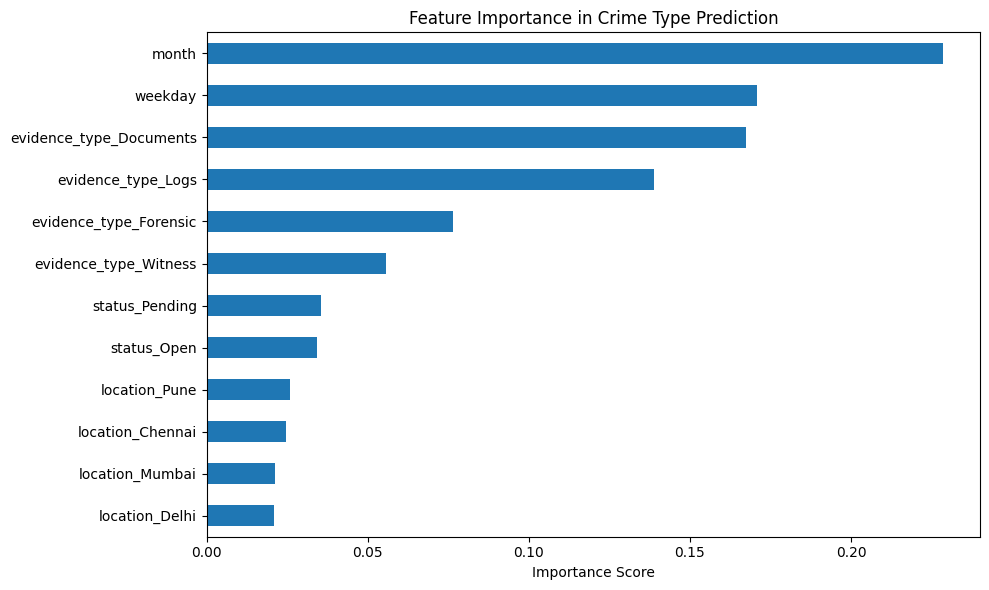

In [26]:
import matplotlib.pyplot as plt

feat_imp = pd.Series(rf_model.feature_importances_, index=X.columns)
feat_imp.sort_values().plot(kind='barh', figsize=(10, 6))
plt.title("Feature Importance in Crime Type Prediction")
plt.xlabel("Importance Score")
plt.tight_layout()
plt.show()

In [27]:
print("=" * 50)
print("CRIME TYPE PREDICTION - MODEL COMPARISON")
print("=" * 50)
print(f"Dataset size: {df.shape[0]} samples")
print(f"Features: {X.shape[1]}")
print(f"Classes: {df['crime_type'].nunique()} crime types")
print()
print("5-Fold Cross Validation Results:")
print(f"  Logistic Regression:     {round(lr_cv.mean(), 3)}")
print(f"  Random Forest default:   {round(rf_cv.mean(), 3)}")
print(f"  Random Forest tuned:     {round(random_search.best_score_, 3)}")
print()
print(f"Best RF parameters: {random_search.best_params_}")
print(f"Improvement from tuning: {round(random_search.best_score_ - rf_cv.mean(), 3)}")
print()
print("Best Model: Logistic Regression (66.2%)")

CRIME TYPE PREDICTION - MODEL COMPARISON
Dataset size: 1000 samples
Features: 12
Classes: 5 crime types

5-Fold Cross Validation Results:
  Logistic Regression:     0.662
  Random Forest default:   0.569
  Random Forest tuned:     0.63

Best RF parameters: {'n_estimators': 200, 'min_samples_split': 5, 'max_depth': 5}
Improvement from tuning: 0.061

Best Model: Logistic Regression (66.2%)
